---
# **General analysis**
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Data = pd.read_csv('TOTF_trade_2014_2017.csv').drop(columns=['source_file'])
print(Data.shape, '\n', Data.head())

(5324786, 4) 
          date      time  trade.price  trade.volume
0  2014-04-14  09:30:03    47.670000         245.0
1  2014-04-14  09:30:04    47.665000         159.0
2  2014-04-14  09:30:04    47.657878         662.0
3  2014-04-14  09:30:04    47.655000         200.0
4  2014-04-14  09:30:04    47.660000         364.0


We compute the Daily data (average price and volume sum)

In [2]:
Daily_data = Data.drop(columns=['time']).groupby(['date']).agg({'trade.price': 'mean','trade.volume': 'sum'}).reset_index()
print(Daily_data.shape, '\n', Daily_data.head())

(768, 3) 
          date  trade.price  trade.volume
0  2014-04-14    48.585520  3.140002e+08
1  2014-04-15    49.286341  4.393999e+08
2  2014-04-16    49.040074  4.345841e+08
3  2014-04-17    46.142495  2.337536e+09
4  2014-04-22    49.593422  2.469515e+08


Let's plot the price evolution over these days !

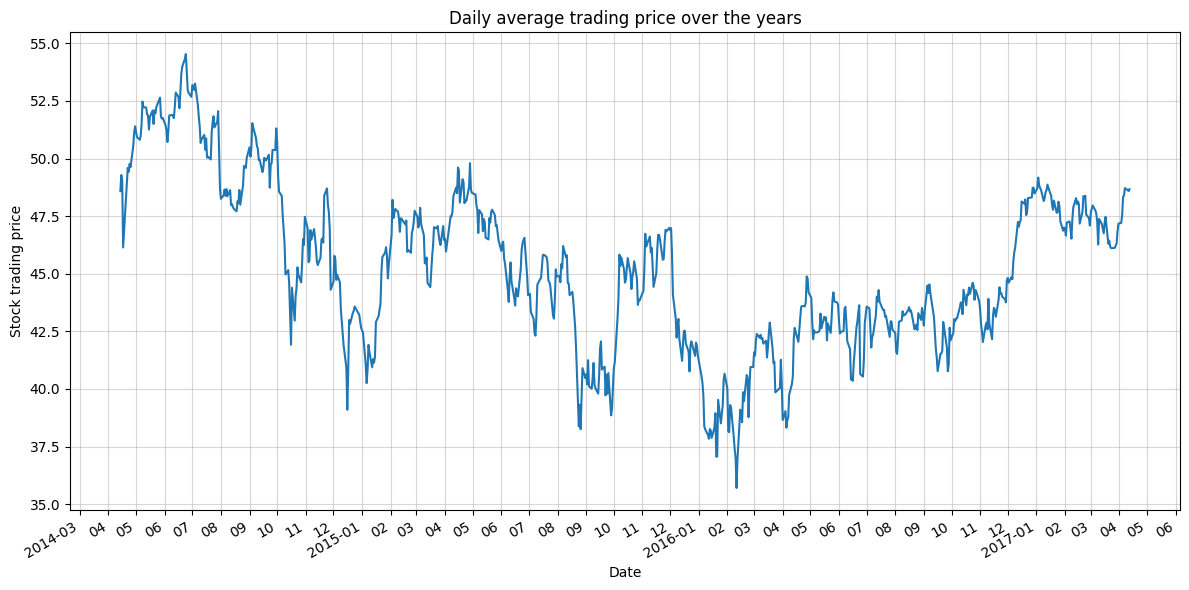

In [3]:
Daily_data['date'] = pd.to_datetime(Daily_data['date'])

from matplotlib.dates import MonthLocator, num2date
from matplotlib.ticker import FuncFormatter

def date_fmt(x, pos=None):
    dt = num2date(x)
    if dt.month == 1 or pos == 0:  # Show year if January or first tick
        return dt.strftime('%Y-%m')
    else:
        return dt.strftime('%m')  # Just month for others
    
plt.figure(figsize=(12, 6))
plt.plot(Daily_data['date'], Daily_data['trade.price'])
plt.gcf().autofmt_xdate()
plt.gca().xaxis.set_major_locator(MonthLocator())
plt.gca().xaxis.set_major_formatter(FuncFormatter(date_fmt))
plt.grid(True, which='major', alpha=0.5)  # Bolder grid for months

plt.xlabel('Date')
plt.ylabel('Stock trading price')
plt.title('Daily average trading price over the years')

plt.tight_layout()
plt.show()

Let's plot the volumes, and compute its mean and standard deviation

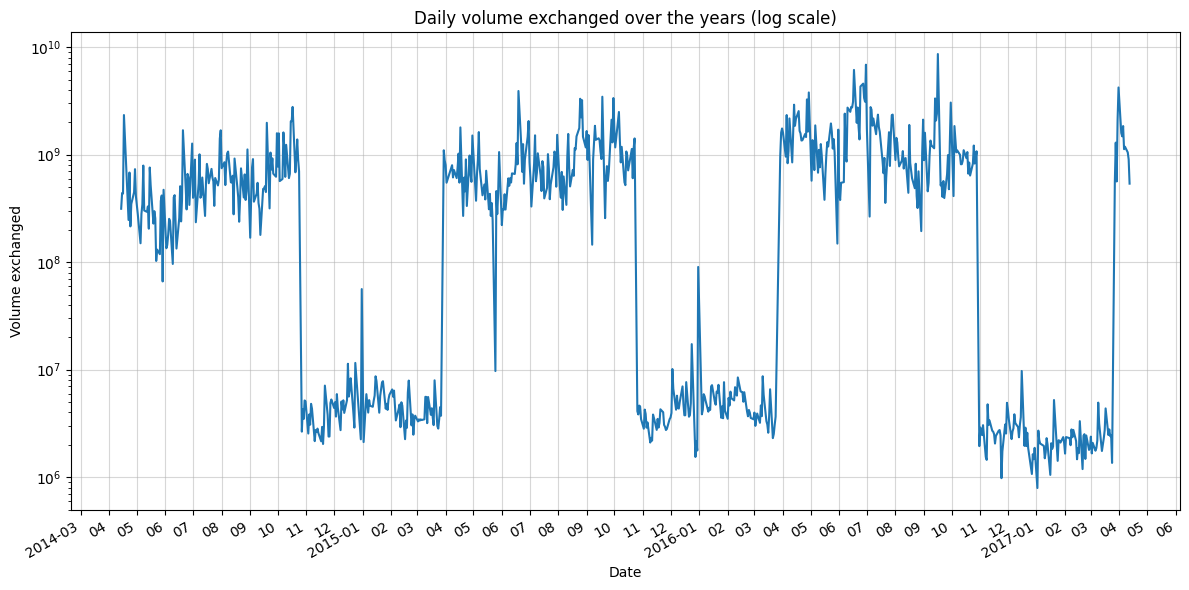

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(Daily_data['date'], Daily_data['trade.volume'])
plt.gcf().autofmt_xdate()
plt.gca().xaxis.set_major_locator(MonthLocator())
plt.gca().xaxis.set_major_formatter(FuncFormatter(date_fmt))
plt.grid(True, which='major', alpha=0.5)  # Bolder grid for months

plt.xlabel('Date')
plt.ylabel('Volume exchanged')
plt.title('Daily volume exchanged over the years (log scale)')
plt.yscale('log')

plt.tight_layout()
plt.show()